In [1]:
import json
import pandas as pd
from urlextract import URLExtract
from urllib.parse import urlparse
import subprocess
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import os
from collections import Counter
import matplotlib.pyplot as plt

os.makedirs("graphs", exist_ok=True)

In [2]:
dic_gpt = json.load(open("../experiments/logs/web_search_URL_gpt-5-nano_True_True.json", "r"))
dic_grok = json.load(open("../experiments/logs/web_search_URL_grok-4.3_True_True.json", "r"))
dic_gemini = json.load(open("../experiments/logs/web_search_URL_gemini-2.5-flash_True_True.json", "r"))

In [3]:
extractor = URLExtract()
def get_redirect_url(url):
    try:
        response = subprocess.run(
            ["curl", "-Ls", "-o", "/dev/null", "-w", "%{url_effective}", url],
            capture_output=True,
            text=True,
            timeout=150
        )
    except:
        return None
    return response.stdout

def extract_urls_resp(res_text, type):
    urls = extractor.find_urls(res_text)

    if type == "gpt":
        urls = [url for url in urls if url.lower().startswith(("http://", "https://"))]

    if type == "gemini":
        urls = [get_redirect_url(url) for url in urls if "https://vertexaisearch.cloud.google.com/grounding-api-redirect/" in url]

    urls = list(set(urls))
    urls = [urlparse(u).netloc for u in urls]

    return urls

def extract_urls(dic, type):
    def process_one(item):
        i, data = item
        urls = extract_urls_resp(data["response"], type)
        return i, urls


    dic_urls = {}

    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [
            executor.submit(process_one, item)
            for item in dic.items()
        ]

        for future in tqdm(as_completed(futures), total=len(futures)):
            i, urls = future.result()
            dic_urls[i] = urls

    return dic_urls

In [4]:
gpt_urls = extract_urls(dic_gpt, "gpt")
grok_urls = extract_urls(dic_grok, "grok")
gem_urls = extract_urls(dic_gemini, "gemini")

100%|██████████| 3578/3578 [11:59<00:00,  4.97it/s]


In [5]:
df = pd.read_csv("../data/CF/cf_v1_test.csv")
df.index = df["claimId"]

def filter(model_urls, domain, lang):
    filtered_urls = {}
    for i, urls in model_urls.items():
        if df.loc[i]["language"] == lang and df.loc[i]["domain"] == domain:
            filtered_urls[i] = urls
            
    return filtered_urls

def return_urls_stats(model_urls, isfilter=False, domain="all", lang="all"):
    if isfilter:
        filtered_urls = filter(model_urls, domain, lang)
    else:
        filtered_urls = model_urls
    tmp1 = [len(urls) for urls in filtered_urls.values()]
    tmp2 = [1 if len(urls)>0 else 0 for urls in filtered_urls.values()]
    
    return f"{domain}--{lang}: {round(sum(tmp1) / len(tmp1), 1)}({round(sum(tmp2)*100 / len(tmp2), 1)})"

print("GPT:")
for d in ["politics", "finance"]:
    for l in ["en", "es", "fr", "ja", "pt"]:
        print(return_urls_stats(gpt_urls, True, d, l))
print(return_urls_stats(gpt_urls))
print("\nGEMINI:")
for d in ["politics", "finance"]:
    for l in ["en", "es", "fr", "ja", "pt"]:
        print(return_urls_stats(gem_urls, True, d, l))
print(return_urls_stats(gem_urls))
print("\nGROK:")
for d in ["politics", "finance"]:
    for l in ["en", "es", "fr", "ja", "pt"]:
        print(return_urls_stats(grok_urls, True, d, l))
print(return_urls_stats(grok_urls))

GPT:
politics--en: 1.4(74.5)
politics--es: 1.3(70.9)
politics--fr: 1.3(69.8)
politics--ja: 1.8(81.8)
politics--pt: 1.3(67.1)
finance--en: 1.3(73.5)
finance--es: 1.4(80.6)
finance--fr: 1.3(70.8)
finance--ja: 1.6(81.1)
finance--pt: 1.1(68.1)
all--all: 1.4(73.1)

GEMINI:
politics--en: 2.4(76.0)
politics--es: 2.6(78.6)
politics--fr: 2.5(74.4)
politics--ja: 2.9(77.6)
politics--pt: 2.2(69.1)
finance--en: 2.5(76.0)
finance--es: 2.4(74.6)
finance--fr: 2.8(79.2)
finance--ja: 3.0(83.5)
finance--pt: 2.3(70.0)
all--all: 2.5(75.4)

GROK:
politics--en: 12.6(98.4)
politics--es: 15.5(99.2)
politics--fr: 12.8(97.0)
politics--ja: 15.0(98.8)
politics--pt: 13.3(98.0)
finance--en: 14.7(98.8)
finance--es: 14.4(99.3)
finance--fr: 15.5(99.1)
finance--ja: 12.5(100.0)
finance--pt: 12.5(96.6)
all--all: 13.9(98.4)


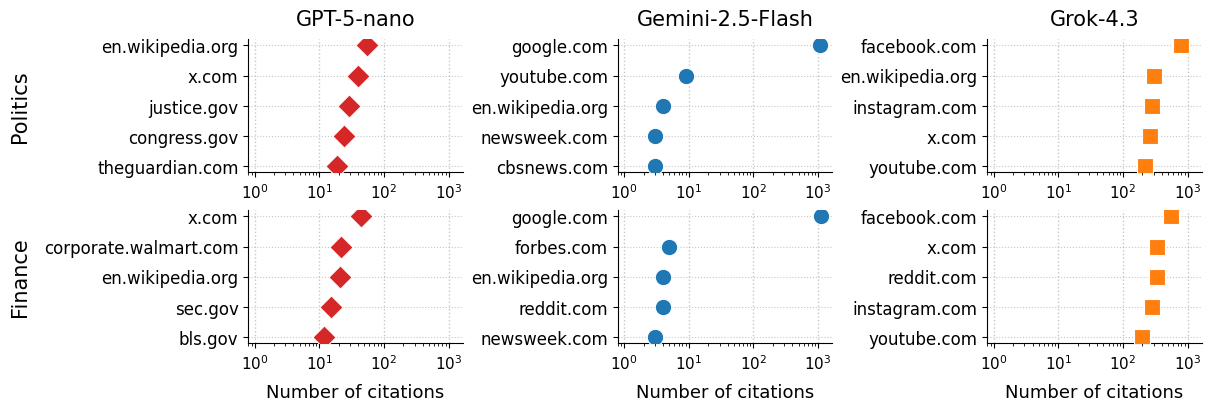

In [6]:
# --- Constants & Setup ---
DOMAINS = ["politics", "finance"]
MODELS = ["GPT-5-nano", "Gemini-2.5-Flash", "Grok-4.3"]
TARGET_LANG = "en"  # Fixing language to English for the main paper figure

MODEL_URLS = {
    "GPT-5-nano": gpt_urls,
    "Gemini-2.5-Flash": gem_urls,
    "Grok-4.3": grok_urls,
}

MODEL_MARKERS = {
    "GPT-5-nano": "D",
    "Gemini-2.5-Flash": "o",
    "Grok-4.3": "s",
}

MODEL_COLORS = {
    "GPT-5-nano": "#d62728",       # Crimson Red
    "Gemini-2.5-Flash": "#1f77b4", # Ocean Blue
    "Grok-4.3": "#ff7f0e",         # Vibrant Orange
}

def clean_domain(x):
    if not isinstance(x, str) or not x.strip():
        return None
    x = x.strip().lower()
    if x.startswith(("http://", "https://")):
        x = urlparse(x).netloc.lower()
    x = x.split("@")[-1].split(":")[0]
    if x.startswith("www."):
        x = x[4:]
    return x or None

def top_domains_for_setting(model_urls, claim_domain, lang, n=10):
    counts = Counter()
    for claim_id, urls in model_urls.items():
        if claim_id not in df.index:
            continue
        row = df.loc[claim_id]
        if row["domain"] == claim_domain and row["language"] == lang:
            counts.update(
                d for d in (clean_domain(u) for u in urls)
                if d
            )
    return counts.most_common(n)


def plot_main_paper_figure(n=10):
    # 2 Rows (Domains) x 3 Columns (Models)
    # Adjusted figsize to 14x8 so it spans nicely across a standard paper width
    fig, axes = plt.subplots(
        nrows=len(DOMAINS),
        ncols=len(MODELS),
        figsize=(12, 4),  
        constrained_layout=True,
    )

    all_max = 1
    all_panels = {}

    # 1. Pre-calculate all data to find the global maximum for a consistent X-axis
    for r, claim_domain in enumerate(DOMAINS):
        for c, model_name in enumerate(MODELS):
            model_urls = MODEL_URLS[model_name]
            top = top_domains_for_setting(model_urls, claim_domain, TARGET_LANG, n=n)
            all_panels[(r, c)] = top
            
            if top:
                all_max = max(all_max, max(v for _, v in top))

    # 2. Plotting loop
    for r, claim_domain in enumerate(DOMAINS):
        for c, model_name in enumerate(MODELS):
            ax = axes[r, c]
            top = all_panels[(r, c)]
            
            # Fetch model-specific styles
            model_color = MODEL_COLORS.get(model_name, "#2ca02c")
            model_marker = MODEL_MARKERS.get(model_name, "D")

            if top:
                labels = [d for d, _ in top][::-1]
                values = [v for _, v in top][::-1]
                y = range(len(labels))

                ax.scatter(
                    values,
                    y,
                    marker=model_marker,
                    c=model_color,
                    edgecolor="white",
                    linewidth=0.8,
                    s=140,
                    zorder=3,
                )

                ax.set_yticks(list(y))
                ax.set_yticklabels(labels, fontsize=12)
            else:
                ax.text(
                    0.5, 0.5, "no citations",
                    ha="center", va="center",
                    transform=ax.transAxes,
                    fontsize=12, color="gray", style='italic'
                )
                ax.set_yticks([])

            # Apply consistent X-axis scale across all subplots
            ax.set_xscale("log")
            ax.set_xlim(0.8, all_max * 1.5)

            # Styling: Grid and Spines
            ax.grid(True, axis="x", which="major", linestyle=":", linewidth=1, zorder=0, alpha=0.7)
            ax.grid(True, axis="y", which="major", linestyle=":", linewidth=0.8, zorder=0, alpha=0.7)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(axis="x", labelsize=11)

            # --- Titles and Labels ---
            
            # Column Titles (Top row): Model Names
            if r == 0:
                ax.set_title(model_name, fontsize=15, pad=10)#, fontweight="bold")

            # Row Labels (Leftmost column): Domain Names
            if c == 0:
                ax.set_ylabel(claim_domain.capitalize(), fontsize=15, labelpad=10)#, fontweight="bold")

            # X-axis Labels (Bottom row)
            if r == len(DOMAINS) - 1:
                ax.set_xlabel("Number of citations", fontsize=13, labelpad=8)

    # Align the Y-labels (Domains) perfectly vertically
    fig.align_ylabels(axes[:, 0])

    fig.savefig("graphs/cf_gs_top_domains_en.pdf", bbox_inches="tight")

    plt.show()

# Execute the plot generation
plot_main_paper_figure(n=5)

Plotting for GPT-5-nano...


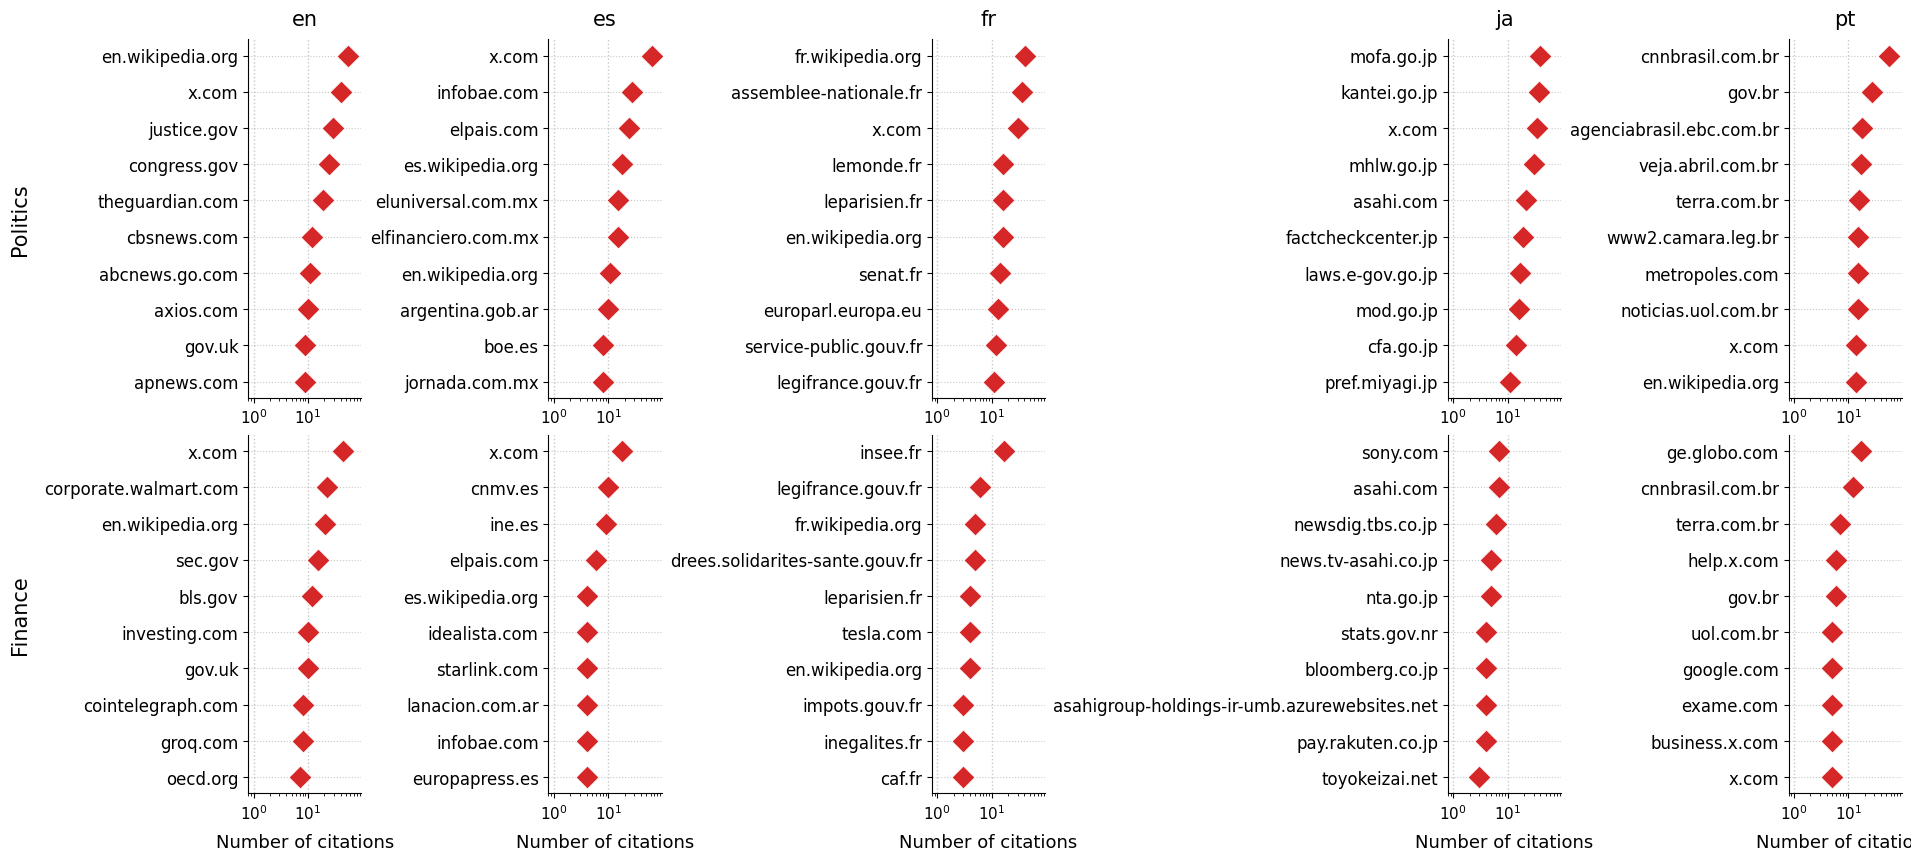

Plotting for Gemini-2.5-Flash...


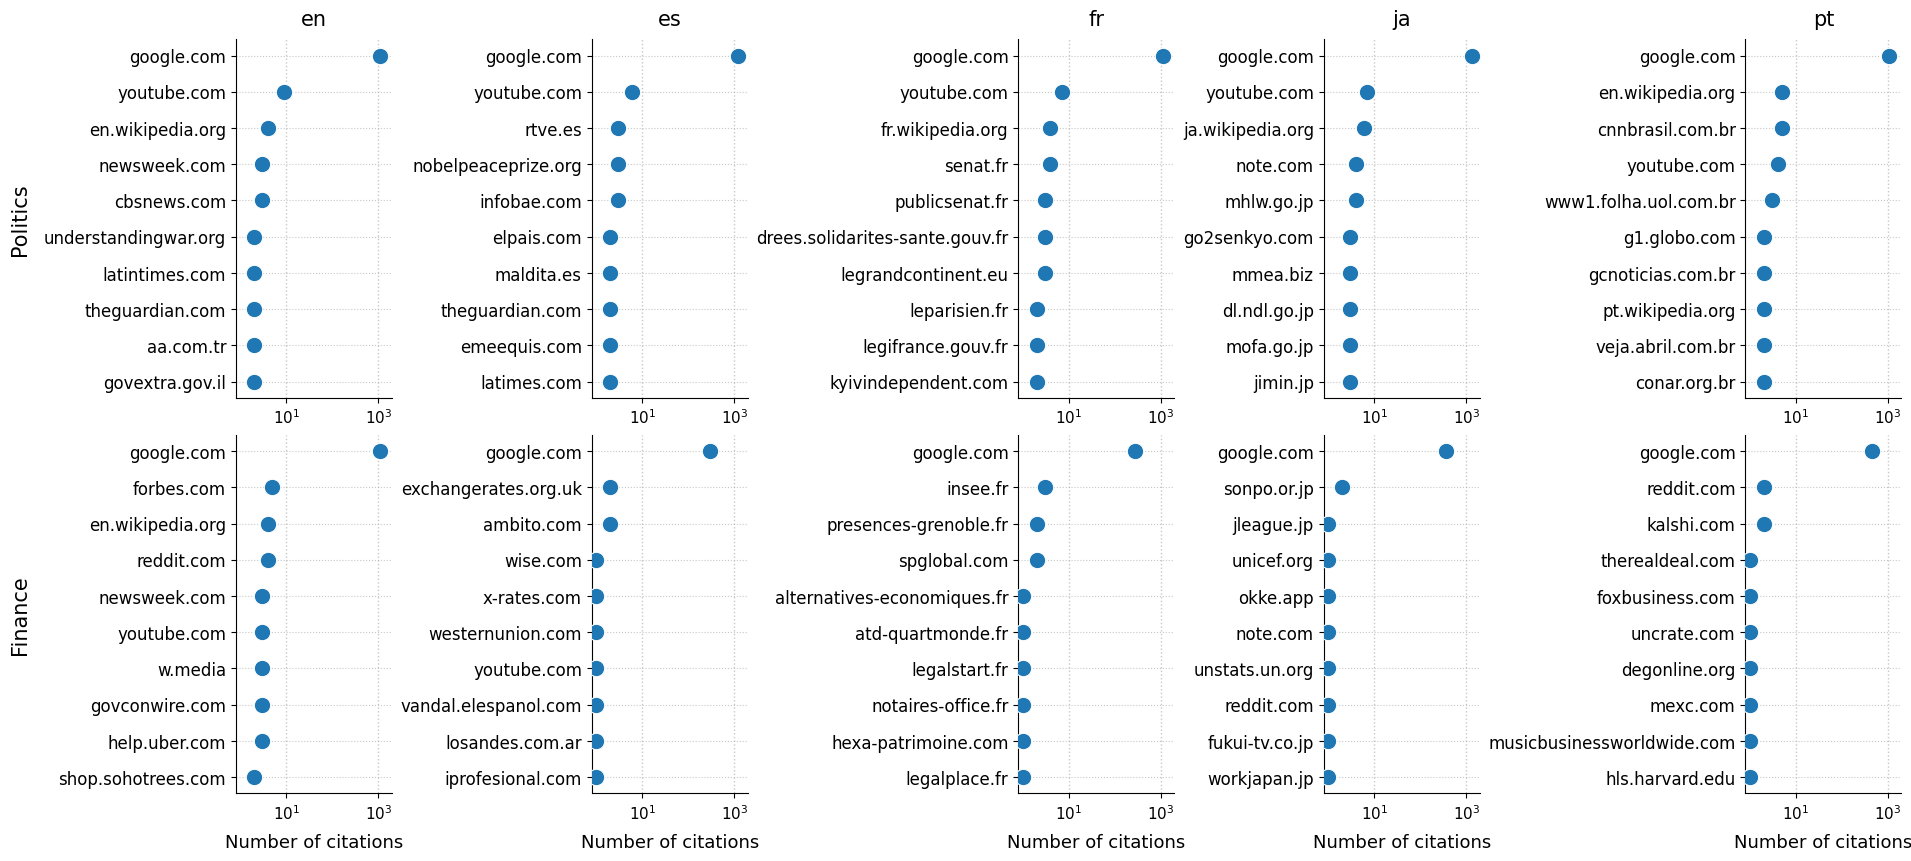

Plotting for Grok-4.3...


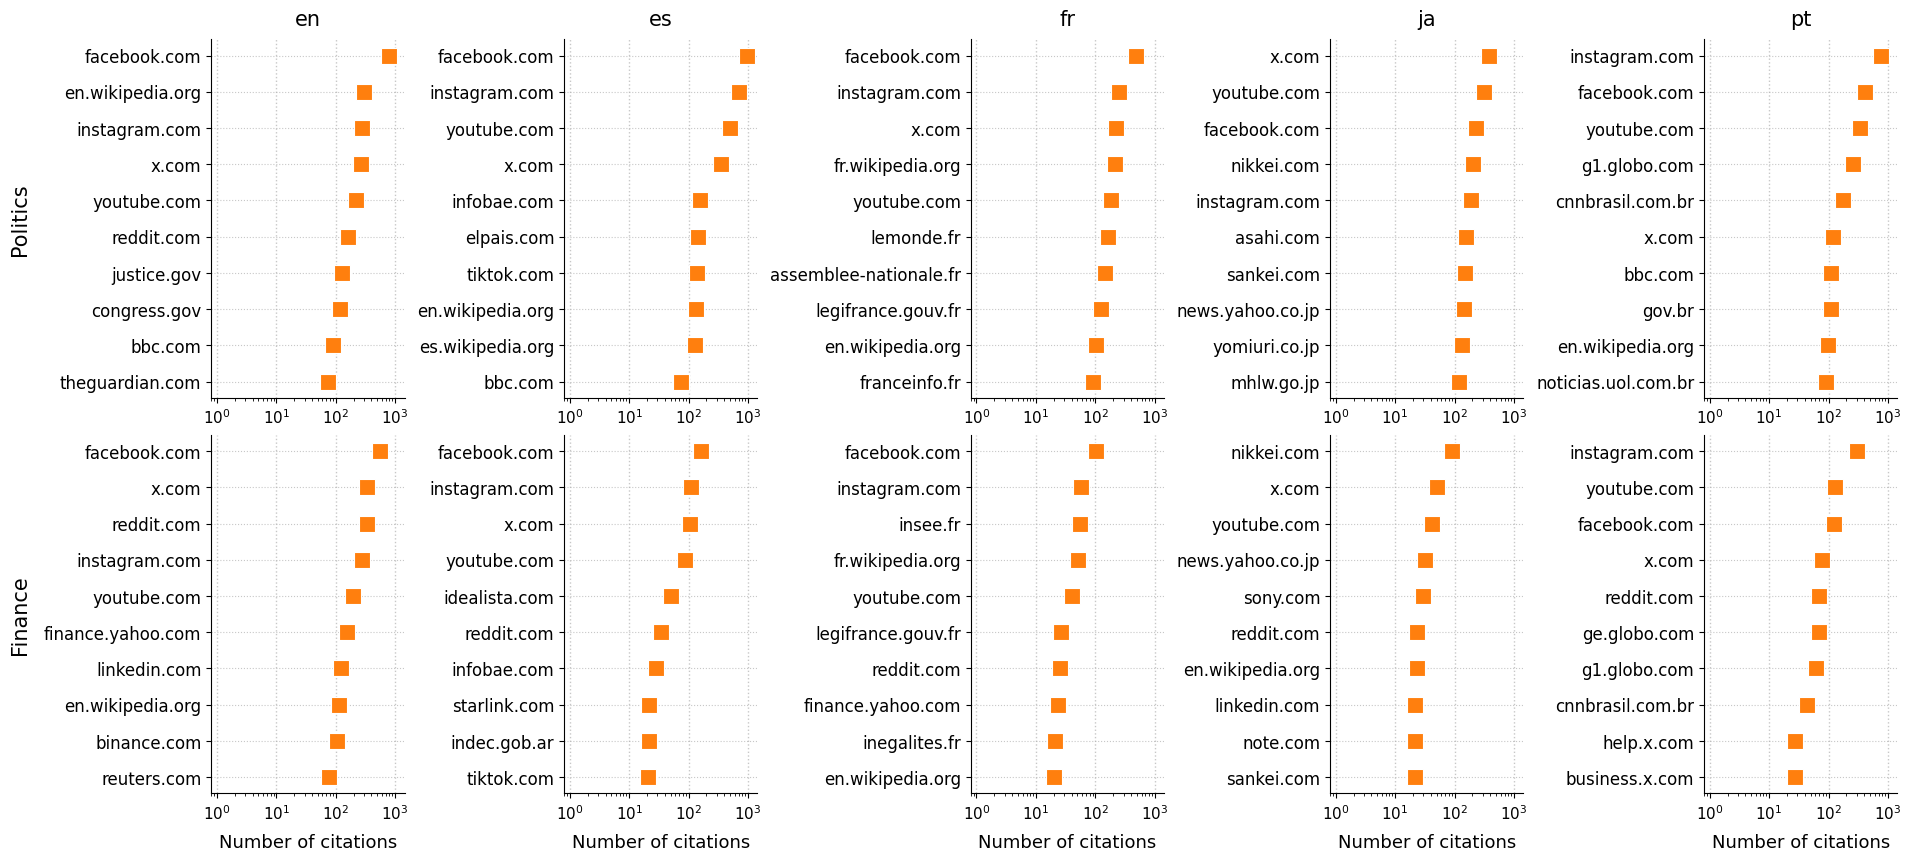

In [7]:
DOMAINS = ["politics", "finance"]
LANGS = ["en", "es", "fr", "ja", "pt"]


def plot_one_model(model_name, model_urls, n=10):
    # 2. INCREASED: Slightly taller figure to accommodate larger fonts
    fig, axes = plt.subplots(
        nrows=len(DOMAINS),
        ncols=len(LANGS),
        figsize=(19, 8.5), 
        constrained_layout=True,
    )

    all_max = 1
    all_panels = {}

    for r, claim_domain in enumerate(DOMAINS):
        for c, lang in enumerate(LANGS):
            top = top_domains_for_setting(model_urls, claim_domain, lang, n=n)
            all_panels[(r, c)] = top

            if top:
                all_max = max(all_max, max(v for _, v in top))

    # Retrieve the specific color for the model being plotted
    model_color = MODEL_COLORS.get(model_name, "#2ca02c")

    for r, claim_domain in enumerate(DOMAINS):
        for c, lang in enumerate(LANGS):
            ax = axes[r, c]
            top = all_panels[(r, c)]

            if top:
                labels = [d for d, _ in top][::-1]
                values = [v for _, v in top][::-1]
                y = range(len(labels))

                # 3. IMPROVED: Larger markers, applied color, added subtle borders, and zorder
                ax.scatter(
                    values,
                    y,
                    marker=MODEL_MARKERS.get(model_name, "D"),
                    c=model_color,
                    edgecolor="white",  # Adds a clean border to the shapes
                    linewidth=0.8,
                    s=140,              # Increased from 55 to 140
                    zorder=3,           # Ensures points draw on top of the grid
                )

                ax.set_yticks(list(y))
                ax.set_yticklabels(labels, fontsize=12) # Increased from 9

            else:
                ax.text(
                    0.5,
                    0.5,
                    "no citations",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=12,
                    color="gray"
                )
                ax.set_yticks([])

            ax.set_xscale("log")
            ax.set_xlim(0.8, all_max * 1.5)

            # 4. CLEANED: Pushed grid behind data, lowered opacity slightly
            ax.grid(True, axis="x", which="major", linestyle=":", linewidth=1, zorder=0, alpha=0.7)
            ax.grid(True, axis="y", which="major", linestyle=":", linewidth=0.8, zorder=0, alpha=0.7)
            
            # Remove top and right box spines for a cleaner aesthetic
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            ax.tick_params(axis="x", labelsize=11) # Increased from 9

            if r == 0:
                ax.set_title(lang, fontsize=15, pad=10) # Increased from 13

            if c == 0:
                ax.set_ylabel(claim_domain.capitalize(), fontsize=15, labelpad=10) # Increased from 13

            if r == len(DOMAINS) - 1:
                ax.set_xlabel("Number of citations", fontsize=13, labelpad=8) # Increased from 11


    # ADD THIS LINE to snap the y-labels ("Politics", "Finance") into perfect vertical alignment
    fig.align_ylabels(axes[:, 0]) 

    fig.savefig(f"graphs/cf_gs_top_domains_{model_name}.pdf", bbox_inches="tight")

    plt.show()


for model_name, model_urls in MODEL_URLS.items():
    print(f"Plotting for {model_name}...")
    plot_one_model(
        model_name,
        model_urls,
        n=10,
    )